# 🎀 Ruban Rose — Notebook 01 : EDA du dataset BreakHis

**Objectif** : Explorer et caractériser le dataset avant tout entraînement.
- Structure des fichiers
- Distribution des classes (bénin / malin)
- Distribution par grossissement (40×, 100×, 200×, 400×)
- Distribution des 8 sous-types tumoraux
- Visualisation d'un échantillon d'images
- Statistiques sur les pixels (moyenne, std) → nécessaires pour la normalisation
- **Intégration du split officiel Fold 1** (`Folds.csv`) → transmission à `02_Preprocessing_Split.ipynb`

> ⚠️ Cette phase est indispensable : elle conditionne toutes les décisions du pipeline.


## 1. Imports & configuration

In [1]:
import os
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Reproductibilité
import random
import torch
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Affichage
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("✅ Imports OK")


✅ Imports OK


## 2. Chargement de la structure des fichiers

In [13]:
# ──────────────────────────────────────────────────────────────
# Adapte ce chemin si besoin — doit pointer vers le dossier
# contenant les dossiers 'benign' et 'malignant' et le fichier Folds.csv
# ──────────────────────────────────────────────────────────────
DATA_ROOT  = Path('../data/ambarish')
FOLDS_PATH = DATA_ROOT / 'Folds.csv'
GRAPH_PATH = Path('../graphs')

assert DATA_ROOT.exists(),  f"❌ Dossier introuvable : {DATA_ROOT}"
assert FOLDS_PATH.exists(), f"❌ Folds.csv introuvable : {FOLDS_PATH}"

print(f"✅ Dataset trouvé   : {DATA_ROOT.resolve()}")
print(f"✅ Folds.csv trouvé : {FOLDS_PATH.resolve()}")


✅ Dataset trouvé   : C:\Users\romua\Documents\La_Plateforme_\Projet 8 - Ruban Rose\ruban-rose\data\ambarish
✅ Folds.csv trouvé : C:\Users\romua\Documents\La_Plateforme_\Projet 8 - Ruban Rose\ruban-rose\data\ambarish\Folds.csv


## 3. Parsing des métadonnées

On extrait depuis les **noms de fichiers** toutes les informations utiles.

Le format BreakHis est :
`SOB_[type]_[sous-type]-[patient_id]-[grossissement]-[num].png`

Exemple : `SOB_B_A-14-22549AB-40-001.png`
- `B` = Bénin, `A` = Adénose, patient `14-22549AB`, grossissement `40`×


In [8]:
records = []

# Correspondance codes → noms complets
subtype_map = {
    'A' : 'Adenosis',
    'F' : 'Fibroadenoma',
    'PT': 'Phyllodes Tumor',
    'TA': 'Tubular Adenoma',
    'DC': 'Ductal Carcinoma',
    'LC': 'Lobular Carcinoma',
    'MC': 'Mucinous Carcinoma',
    'PC': 'Papillary Carcinoma',
}

for img_path in DATA_ROOT.rglob('*.png'):
    parts = img_path.parts
    # Détecter la classe depuis le chemin
    if 'benign' in [p.lower() for p in parts]:
        label     = 'Benign'
        label_int = 0
    elif 'malignant' in [p.lower() for p in parts]:
        label     = 'Malignant'
        label_int = 1
    else:
        continue

    fname = img_path.stem  # sans extension
    # Pattern : SOB_[BM]_[SOUS-TYPE]-[PATIENT]-[MAGNIF]-[NUM]
    # Utilisation d'un pattern non-greedy pour isoler correctement le patient_id
    match = re.match(
        r'SOB_[BM]_([A-Z]+)-(.+?)-(\d+)-(\d+)$',
        fname, re.IGNORECASE
    )
    if match:
        subtype_code  = match.group(1).upper()
        patient_id    = match.group(2)
        magnification = int(match.group(3))
    else:
        subtype_code  = 'Unknown'
        patient_id    = 'Unknown'
        magnification = 0

    records.append({
        'path'         : str(img_path),
        'filename'     : img_path.name,
        'label'        : label,
        'label_int'    : label_int,
        'subtype_code' : subtype_code,
        'subtype'      : subtype_map.get(subtype_code, subtype_code),
        'patient_id'   : patient_id,
        'magnification': magnification,
    })

df = pd.DataFrame(records)

# Contrôle de cohérence
n_unknown = (df['patient_id'] == 'Unknown').sum()
if n_unknown > 0:
    print(f"⚠️  {n_unknown} fichiers n'ont pas pu être parsés (vérifier le format)")

print(f"✅ {len(df):,} images chargées")
print(f"   Patients distincts : {df['patient_id'].nunique()}")
print(f"   Sous-types trouvés : {sorted(df['subtype_code'].unique())}")
df.head()


✅ 7,909 images chargées
   Patients distincts : 81
   Sous-types trouvés : ['A', 'DC', 'F', 'LC', 'MC', 'PC', 'PT', 'TA']


,path,filename,label,label_int,subtype_code,subtype,patient_id,magnification
0,..\data\ambarish\benign\SOB\adenosis\SOB_B_A_1...,SOB_B_A-14-22549AB-100-001.png,Benign,0,A,Adenosis,14-22549AB,100
1,..\data\ambarish\benign\SOB\adenosis\SOB_B_A_1...,SOB_B_A-14-22549AB-100-002.png,Benign,0,A,Adenosis,14-22549AB,100
2,..\data\ambarish\benign\SOB\adenosis\SOB_B_A_1...,SOB_B_A-14-22549AB-100-003.png,Benign,0,A,Adenosis,14-22549AB,100
3,..\data\ambarish\benign\SOB\adenosis\SOB_B_A_1...,SOB_B_A-14-22549AB-100-004.png,Benign,0,A,Adenosis,14-22549AB,100
4,..\data\ambarish\benign\SOB\adenosis\SOB_B_A_1...,SOB_B_A-14-22549AB-100-005.png,Benign,0,A,Adenosis,14-22549AB,100


## 4. Distribution globale des classes

In [9]:
print("=" * 45)
print("  DISTRIBUTION GLOBALE DES CLASSES")
print("=" * 45)

class_counts = df['label'].value_counts()
for label, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  {label:12s} : {count:5,} images ({pct:.1f}%)")

print(f"  {'TOTAL':12s} : {len(df):5,} images")
print()
print(f"  Ratio déséquilibre : 1 : {class_counts.max()/class_counts.min():.2f}")
print()
print("⚠️  Un modèle trivial qui prédit toujours 'Malignant'")
print(f"   obtiendrait {class_counts['Malignant']/len(df)*100:.1f}% d'accuracy sans rien apprendre.")


  DISTRIBUTION GLOBALE DES CLASSES
  Malignant    : 5,429 images (68.6%)
  Benign       : 2,480 images (31.4%)
  TOTAL        : 7,909 images

  Ratio déséquilibre : 1 : 2.19

⚠️  Un modèle trivial qui prédit toujours 'Malignant'
   obtiendrait 68.6% d'accuracy sans rien apprendre.


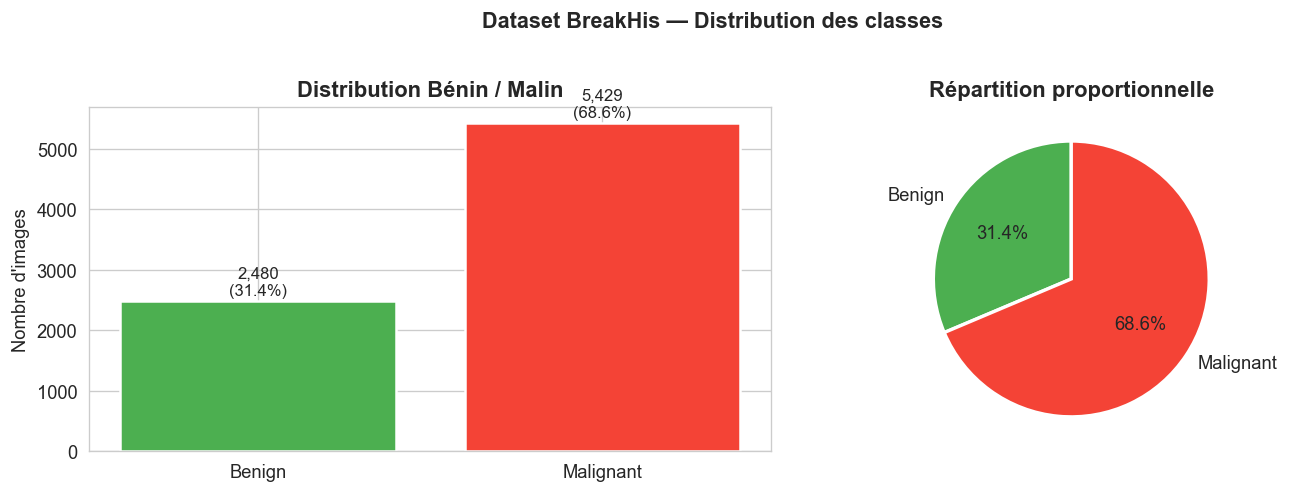

✅ Graphique sauvegardé : ..\graphs\eda_01_class_distribution.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4CAF50', '#F44336']
color_map = {'Benign': '#4CAF50', 'Malignant': '#F44336'}
class_counts = df['label'].value_counts().reindex(['Benign', 'Malignant'])
colors = [color_map[label] for label in class_counts.index]
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution Bénin / Malin', fontweight='bold')
axes[0].set_ylabel("Nombre d'images")
for i, (label, count) in enumerate(class_counts.items()):
    axes[0].text(i, count + 50, f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition proportionnelle', fontweight='bold')

plt.suptitle('Dataset BreakHis — Distribution des classes', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'eda_01_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Graphique sauvegardé : " + str(GRAPH_PATH / 'eda_01_class_distribution.png'))


## 5. Distribution par grossissement

Les 4 grossissements ne donnent pas les mêmes informations biologiques :
- **40×** : architecture tissulaire globale (patterns larges)
- **100×** / **200×** : groupes cellulaires
- **400×** : détails nucléaires fins (plus difficile pour un modèle)


In [31]:
mag_counts = df.groupby(['magnification', 'label']).size().unstack(fill_value=0)
mag_counts = mag_counts.reindex([40, 100, 200, 400])

print("Distribution par grossissement :")
print(mag_counts)
print()
for mag in [40, 100, 200, 400]:
    sub      = df[df['magnification'] == mag]
    n_benign = (sub['label'] == 'Benign').sum()
    n_malig  = (sub['label'] == 'Malignant').sum()
    print(f"  {mag:>3}× : {len(sub):4} images | "
          f"Bénin {n_benign:4} ({n_benign/len(sub)*100:.1f}%) | "
          f"Malin {n_malig:4} ({n_malig/len(sub)*100:.1f}%)")


Distribution par grossissement :
label          Benign  Malignant
magnification                   
40                625       1370
100               644       1437
200               623       1390
400               588       1232

   40× : 1995 images | Bénin  625 (31.3%) | Malin 1370 (68.7%)
  100× : 2081 images | Bénin  644 (30.9%) | Malin 1437 (69.1%)
  200× : 2013 images | Bénin  623 (30.9%) | Malin 1390 (69.1%)
  400× : 1820 images | Bénin  588 (32.3%) | Malin 1232 (67.7%)


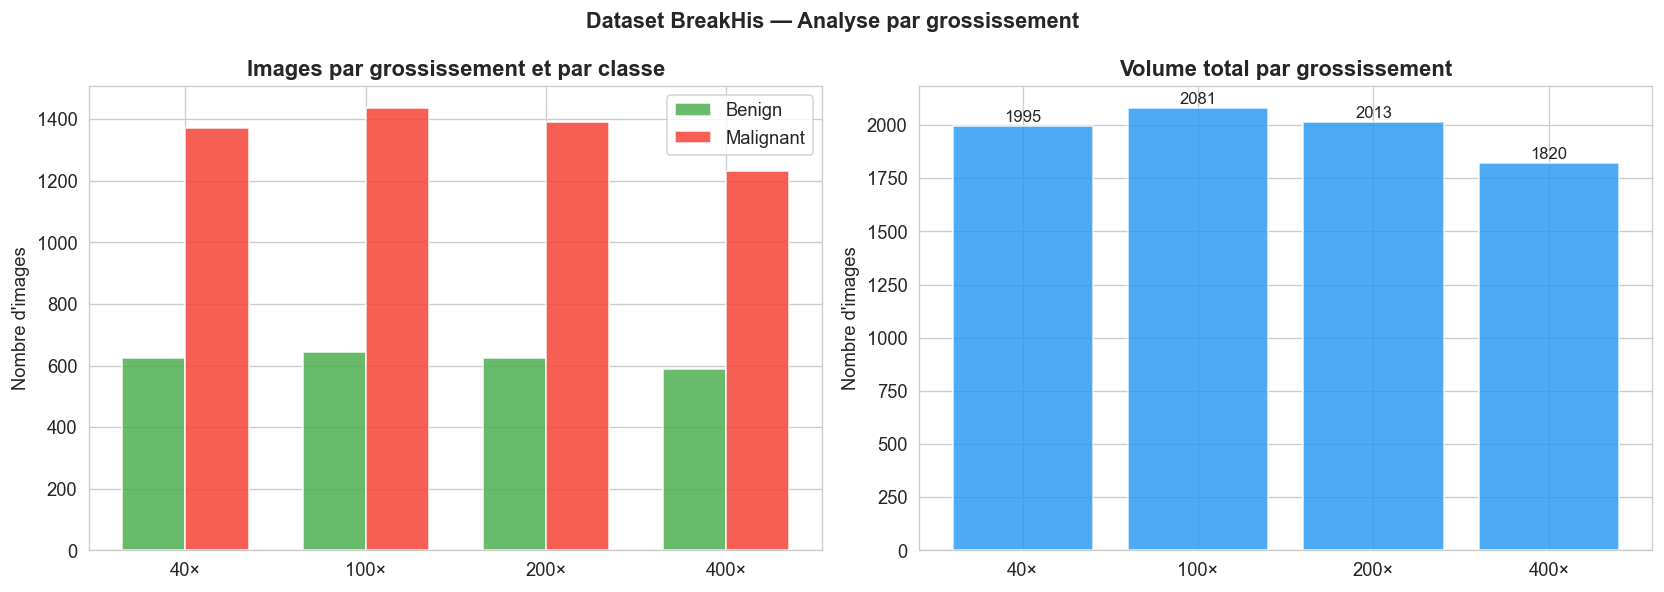

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x     = np.arange(len(mag_counts))
width = 0.35
axes[0].bar(x - width/2, mag_counts['Benign'],    width, label='Benign',    color='#4CAF50', alpha=0.85)
axes[0].bar(x + width/2, mag_counts['Malignant'], width, label='Malignant', color='#F44336', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{m}×' for m in mag_counts.index])
axes[0].set_title('Images par grossissement et par classe', fontweight='bold')
axes[0].set_ylabel("Nombre d'images")
axes[0].legend()

total_per_mag = df['magnification'].value_counts().sort_index()
axes[1].bar([f'{m}×' for m in total_per_mag.index],
            total_per_mag.values, color='#2196F3', alpha=0.8)
axes[1].set_title('Volume total par grossissement', fontweight='bold')
axes[1].set_ylabel("Nombre d'images")
for i, v in enumerate(total_per_mag.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=10)

plt.suptitle('Dataset BreakHis — Analyse par grossissement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'eda_02_magnification_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Distribution des 8 sous-types tumoraux

In [33]:
subtype_counts = df.groupby(['label', 'subtype']).size().reset_index(name='count')

print("Sous-types BÉNINS :")
benign_sub = subtype_counts[subtype_counts['label'] == 'Benign'].sort_values('count', ascending=False)
for _, row in benign_sub.iterrows():
    print(f"  {row['subtype']:25s} : {row['count']:4} images")

print("\nSous-types MALINS :")
malig_sub = subtype_counts[subtype_counts['label'] == 'Malignant'].sort_values('count', ascending=False)
for _, row in malig_sub.iterrows():
    print(f"  {row['subtype']:25s} : {row['count']:4} images")


Sous-types BÉNINS :
  Fibroadenoma              : 1014 images
  Tubular Adenoma           :  569 images
  Phyllodes Tumor           :  453 images
  Adenosis                  :  444 images

Sous-types MALINS :
  Ductal Carcinoma          : 3451 images
  Mucinous Carcinoma        :  792 images
  Lobular Carcinoma         :  626 images
  Papillary Carcinoma       :  560 images


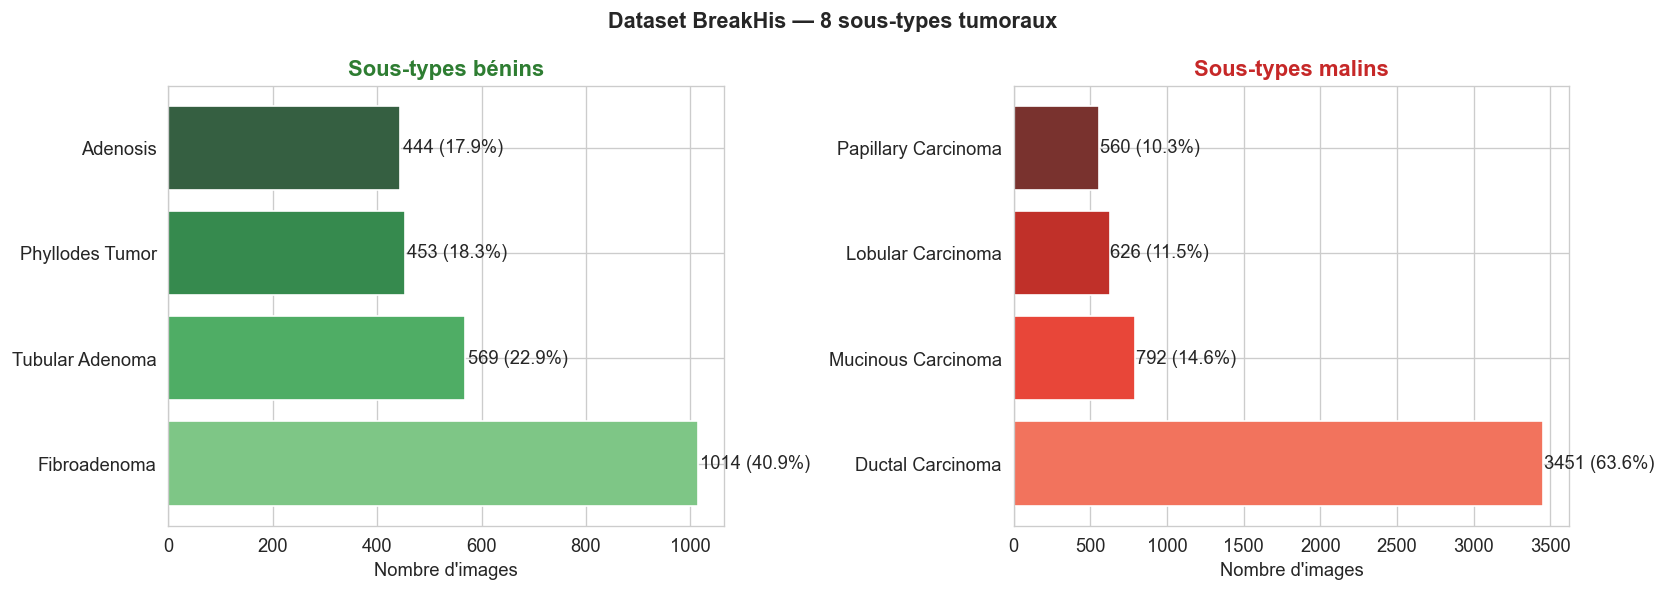

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_b = sns.color_palette('Greens_d', len(benign_sub))
palette_m = sns.color_palette('Reds_d',   len(malig_sub))

axes[0].barh(benign_sub['subtype'], benign_sub['count'], color=palette_b)
axes[0].set_title('Sous-types bénins', fontweight='bold', color='#2E7D32')
axes[0].set_xlabel("Nombre d'images")
total_b = benign_sub['count'].sum()
for i, v in enumerate(benign_sub['count']):
    axes[0].text(v + 5, i, f"{v} ({v/total_b*100:.1f}%)", va='center')

axes[1].barh(malig_sub['subtype'], malig_sub['count'], color=palette_m)
axes[1].set_title('Sous-types malins', fontweight='bold', color='#C62828')
axes[1].set_xlabel("Nombre d'images")
total_m = malig_sub['count'].sum()
for i, v in enumerate(malig_sub['count']):
    axes[1].text(v + 5, i, f"{v} ({v/total_m*100:.1f}%)", va='center')

plt.suptitle('Dataset BreakHis — 8 sous-types tumoraux', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'eda_03_subtype_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Distribution des patients

In [35]:
n_patients_total  = df['patient_id'].nunique()
n_patients_benign = df[df['label']=='Benign']['patient_id'].nunique()
n_patients_malig  = df[df['label']=='Malignant']['patient_id'].nunique()

print(f"Patients total  : {n_patients_total}")
print(f"Patients bénins : {n_patients_benign}")
print(f"Patients malins : {n_patients_malig}")
print()

imgs_per_patient = df.groupby('patient_id').size()
print(f"Images / patient : min={imgs_per_patient.min()} | "
      f"max={imgs_per_patient.max()} | "
      f"moyenne={imgs_per_patient.mean():.1f}")
print()
print("⚠️  Point critique : le split train/val/test utilise le Fold 1 officiel")
print("   du fichier Folds.csv — garantit la séparation stricte par patient.")
print("   → Voir Section 12 pour l'intégration du split Fold 1.")


Patients total  : 81
Patients bénins : 24
Patients malins : 57

Images / patient : min=38 | max=246 | moyenne=97.6

⚠️  Point critique : le split train/val/test utilise le Fold 1 officiel
   du fichier Folds.csv — garantit la séparation stricte par patient.
   → Voir Section 12 pour l'intégration du split Fold 1.


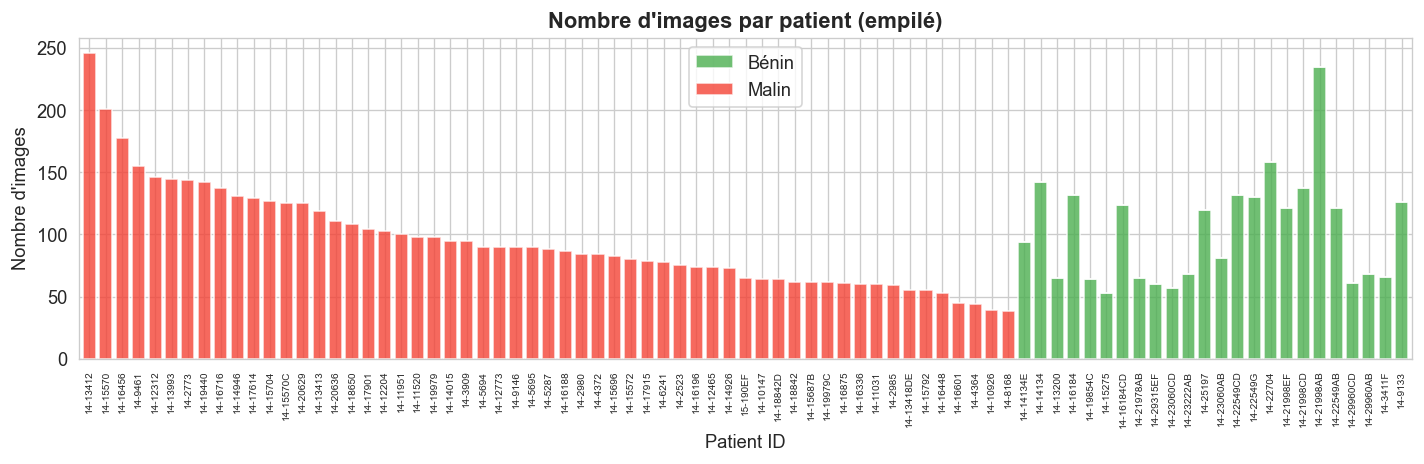

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))

imgs_per_patient_labeled = df.groupby(['patient_id', 'label']).size().unstack(fill_value=0)
imgs_per_patient_labeled = imgs_per_patient_labeled.sort_values('Malignant', ascending=False)

imgs_per_patient_labeled['Benign'].plot(
    kind='bar', ax=ax, color='#4CAF50', label='Bénin', alpha=0.8, width=0.8)
imgs_per_patient_labeled['Malignant'].plot(
    kind='bar', ax=ax, color='#F44336', label='Malin', alpha=0.8, width=0.8,
    bottom=imgs_per_patient_labeled['Benign'])

ax.set_title("Nombre d'images par patient (empilé)", fontweight='bold')
ax.set_ylabel("Nombre d'images")
ax.set_xlabel('Patient ID')
ax.legend()
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'eda_04_images_per_patient.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Visualisation d'un échantillon d'images

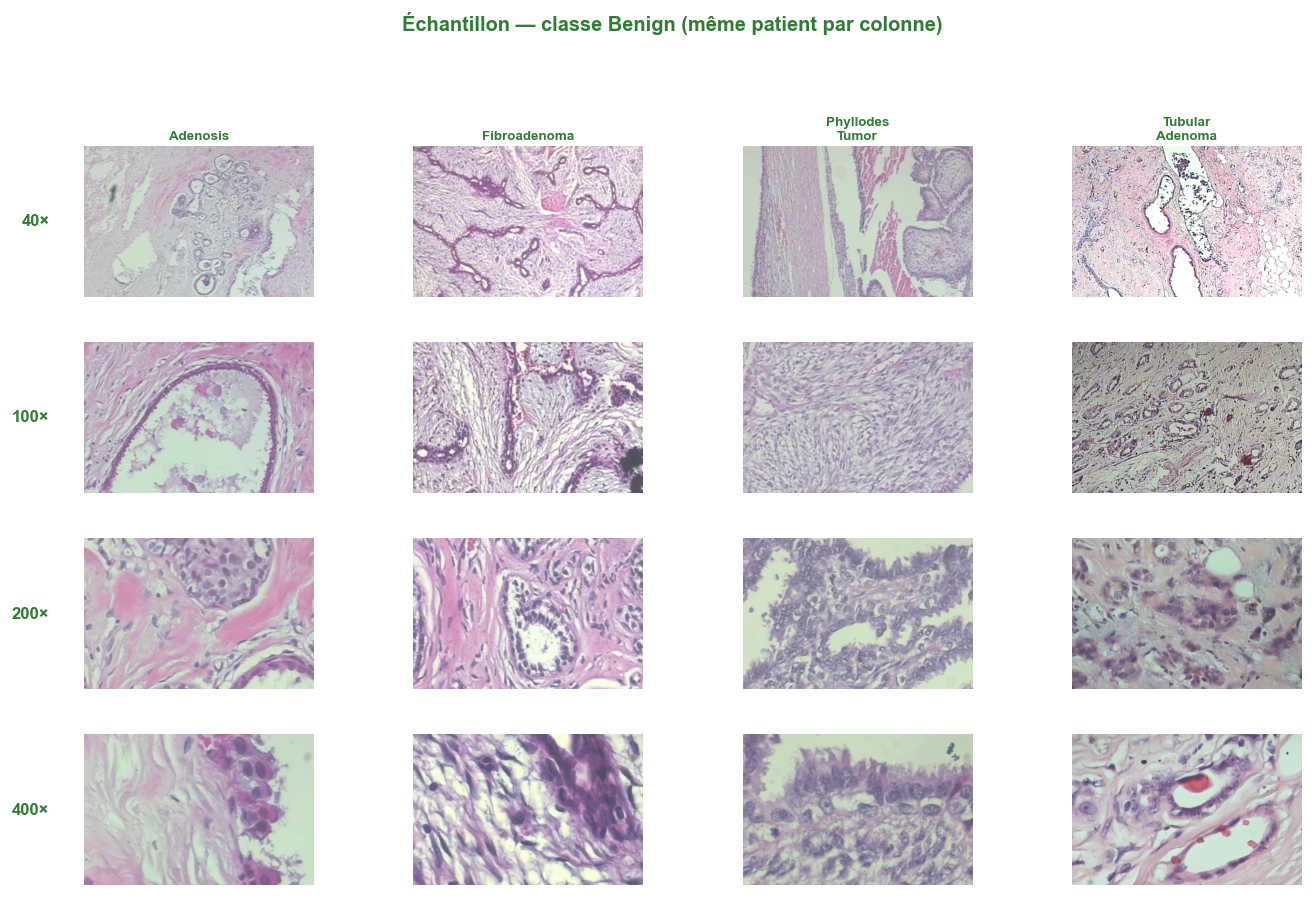

✅ Sauvegardé : ..\graphs/eda_05_sample_benign.png


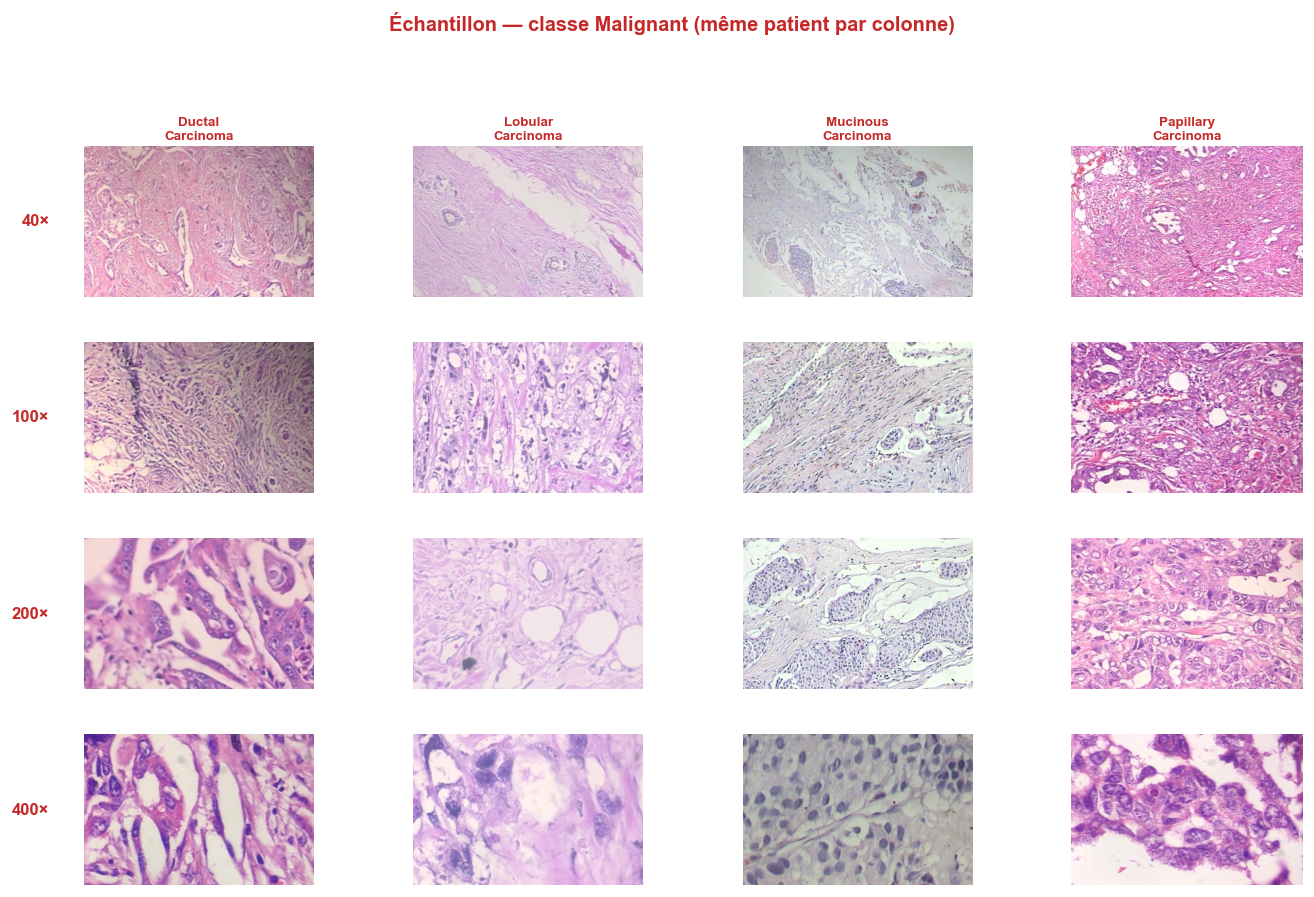

✅ Sauvegardé : ..\graphs/eda_05_sample_malignant.png


In [38]:
def show_comparison_grid(df, label, figsize=(14, 8)):
    magnifications = [40, 100, 200, 400]
    color = '#2E7D32' if label == 'Benign' else '#C62828'
    subtypes = sorted(df[df['label'] == label]['subtype'].unique())

    def pick_patient(subtype):
        sub = df[df['subtype'] == subtype]
        for pid in sub['patient_id'].unique():
            mags = sub[sub['patient_id'] == pid]['magnification'].unique()
            if all(m in mags for m in magnifications):
                return pid
        return sub['patient_id'].iloc[0]

    fig, axes = plt.subplots(len(magnifications), len(subtypes),
                             figsize=figsize,
                             gridspec_kw={'hspace': 0.3, 'wspace': 0.05})

    for col_idx, subtype in enumerate(subtypes):
        patient = pick_patient(subtype)
        sub = df[(df['subtype'] == subtype) & (df['patient_id'] == patient)]

        axes[0, col_idx].set_title(
            subtype.replace(' ', '\n'), fontsize=8,
            fontweight='bold', color=color, pad=4
        )

        for row_idx, mag in enumerate(magnifications):
            ax = axes[row_idx, col_idx]
            img_row = sub[sub['magnification'] == mag]
            if len(img_row) > 0:
                img = Image.open(img_row.iloc[0]['path'])
                ax.imshow(img)
            ax.axis('off')

            # ← fix : text() fonctionne même avec axis('off')
            if col_idx == 0:
                ax.text(-0.15, 0.5, f'{mag}×', fontsize=10, fontweight='bold',
                        color=color, transform=ax.transAxes,
                        ha='right', va='center')

    fig.suptitle(f'Échantillon — classe {label} (même patient par colonne)',
                 fontsize=12, fontweight='bold', color=color, y=1.02)
    plt.savefig(f'{GRAPH_PATH}/eda_05_sample_{label.lower()}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"✅ Sauvegardé : {GRAPH_PATH}/eda_05_sample_{label.lower()}.png")

show_comparison_grid(df, 'Benign')
show_comparison_grid(df, 'Malignant')

## 9. Statistiques sur les pixels

On calcule la moyenne et l'écart-type par canal RGB sur un échantillon.
Ces valeurs seront utilisées pour la normalisation dans le notebook 02.

> 💡 Si les valeurs sont proches de `[0.485, 0.456, 0.406]` et `[0.229, 0.224, 0.225]`
> (standards ImageNet), la normalisation ImageNet est justifiée. Sinon, on pourrait
> calculer des valeurs spécifiques au dataset.


In [39]:
SAMPLE_SIZE = 500
sample_paths = df['path'].sample(SAMPLE_SIZE, random_state=42).tolist()

means, stds = [], []
print(f"Calcul sur {SAMPLE_SIZE} images...")

for path in tqdm(sample_paths):
    img = np.array(Image.open(path).convert('RGB').resize((224, 224))) / 255.0
    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

mean_rgb = np.array(means).mean(axis=0)
std_rgb  = np.array(stds).mean(axis=0)

print(f"\n📊 Statistiques RGB sur {SAMPLE_SIZE} images :")
print(f"   Moyenne : R={mean_rgb[0]:.3f}  G={mean_rgb[1]:.3f}  B={mean_rgb[2]:.3f}")
print(f"   Std     : R={std_rgb[0]:.3f}  G={std_rgb[1]:.3f}  B={std_rgb[2]:.3f}")
print()
print("   Référence ImageNet :")
print("   Moyenne : R=0.485  G=0.456  B=0.406")
print("   Std     : R=0.229  G=0.224  B=0.225")

# Stocker pour export
DATASET_MEAN = mean_rgb.tolist()
DATASET_STD  = std_rgb.tolist()


Calcul sur 500 images...


100%|██████████| 500/500 [00:05<00:00, 98.82it/s] 


📊 Statistiques RGB sur 500 images :
   Moyenne : R=0.784  G=0.627  B=0.760
   Std     : R=0.103  G=0.135  B=0.086

   Référence ImageNet :
   Moyenne : R=0.485  G=0.456  B=0.406
   Std     : R=0.229  G=0.224  B=0.225


## 10. Vérification des dimensions

In [40]:
sample_paths_size = df['path'].sample(min(200, len(df)), random_state=42).tolist()
sizes = set()
for path in sample_paths_size:
    img = Image.open(path)
    sizes.add(img.size)  # (width, height)

print(f"Dimensions trouvées (W×H) : {sizes}")
if len(sizes) == 1:
    w, h = list(sizes)[0]
    print(f"✅ Toutes les images font {w}×{h} px → resize vers 224×224 nécessaire")
else:
    print("⚠️  Dimensions variables → resize encore plus important")


Dimensions trouvées (W×H) : {(700, 460), (700, 456)}
⚠️  Dimensions variables → resize encore plus important


## 11. Heatmap : grossissement × sous-type

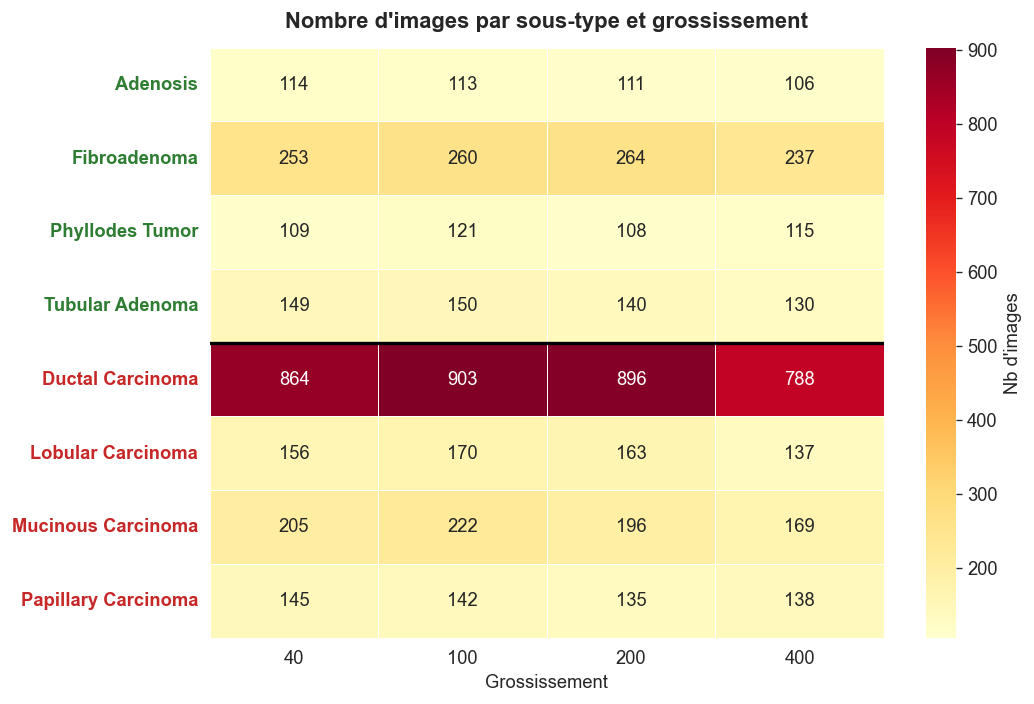

In [48]:
n_b = len(benign_subtypes)
n_m = len(malig_subtypes)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': "Nb d'images"})

# Labels Y colorés
for tick in ax.get_yticklabels():
    color = '#2E7D32' if tick.get_text() in benign_subtypes else '#C62828'
    tick.set_color(color)
    tick.set_fontweight('bold')

ax.axhline(n_b, color='black', linewidth=2)
ax.set_title("Nombre d'images par sous-type et grossissement",
             fontweight='bold', pad=12)
ax.set_xlabel('Grossissement')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(GRAPH_PATH / 'eda_06_heatmap_subtype_magnification.png', bbox_inches='tight', dpi=150)
plt.show()

## 12. Intégration du Split officiel — Fold 1

> 🔑 **Pourquoi utiliser le Fold 1 officiel ?**
> Au lieu d'un split aléatoire (`random_state=42`), on utilise le fichier `Folds.csv`
> fourni avec le dataset BreakHis. Ce fichier garantit :
> - La **reproductibilité** pour comparer avec les résultats de l'état de l'art
> - La **séparation stricte des patients** entre train et test (pas de data leakage)
>
> **Structure de `Folds.csv`** :
> | `filename` | `fold` | `grp` |
> |---|---|---|
> | `SOB_M_DC-14-2523-100-008.png` | 1 | `train` |
> | `SOB_B_A-14-22549AB-40-001.png` | 1 | `test` |
>
> Un set de **validation** (Early Stopping) sera extrait du train dans `02_Preprocessing_Split.ipynb`
> en séparant **par patient** (15% des patients train).


In [49]:
from sklearn.model_selection import train_test_split

# ── 1. Charger Folds.csv ─────────────────────────────────────────────────────
df_folds = pd.read_csv(FOLDS_PATH)
print("Colonnes de Folds.csv :", df_folds.columns.tolist())
print(f"Folds disponibles    : {sorted(df_folds['fold'].unique())}")
print(f"Total lignes         : {len(df_folds):,}")
print()
df_folds.head(3)


Colonnes de Folds.csv : ['fold', 'mag', 'grp', 'filename']
Folds disponibles    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Total lignes         : 39,545



,fold,mag,grp,filename
0,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
1,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
2,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...


In [54]:
# ── 2. Filtrer pour le Fold 1 uniquement ─────────────────────────────────────
df_fold1 = df_folds[df_folds['fold'] == 1].copy()

print(f"Fold 1 — total   : {len(df_fold1):,} entrées")
print(f"  grp='train'    : {(df_fold1['grp']=='train').sum():,}")
print(f"  grp='test'     : {(df_fold1['grp']=='test').sum():,}")

# ── Fix data leakage : retirer du test les patients présents dans les deux ────
# Anomalie connue du Folds.csv Kaggle — 1 patient en commun train/test
train_files = set(df_fold1[df_fold1['grp'] == 'train']['filename'])
test_files  = set(df_fold1[df_fold1['grp'] == 'test']['filename'])

# Identifier via le patient_id extrait du filename
df_fold1['patient_id_tmp'] = df_fold1['filename'].apply(
    lambda f: re.search(r'SOB_[MB]_[A-Z]+-(.+?)-\d+-\d+', Path(f).stem)
).apply(lambda m: m.group(1) if m else None)

train_pts   = set(df_fold1[df_fold1['grp'] == 'train']['patient_id_tmp'])
test_pts    = set(df_fold1[df_fold1['grp'] == 'test']['patient_id_tmp'])
overlap_pts = train_pts & test_pts

if overlap_pts:
    print(f"\n⚠️  {len(overlap_pts)} patient(s) en commun détecté(s) : {overlap_pts}")
    # On retire du test (on garde dans train = plus grand set)
    df_fold1 = df_fold1[~(
        df_fold1['patient_id_tmp'].isin(overlap_pts) &
        (df_fold1['grp'] == 'test')
    )]
    print(f"✅ Retiré du test — Fold 1 propre : {len(df_fold1):,} entrées")

df_fold1 = df_fold1.drop(columns=['patient_id_tmp'])

# ── 3. Normaliser le filename pour la jointure ────────────────────────────────
df_fold1['filename_base'] = df_fold1['filename'].apply(lambda f: Path(f).name)

# ── 4. Jointure avec df ───────────────────────────────────────────────────────
df_merged = df.merge(
    df_fold1[['filename_base', 'grp']],
    left_on='filename',
    right_on='filename_base',
    how='left'
).drop(columns=['filename_base'])

n_matched   = df_merged['grp'].notna().sum()
n_unmatched = df_merged['grp'].isna().sum()
print(f"\nJointure avec df :")
print(f"  ✅ Images matchées avec Fold 1 : {n_matched:,}")
print(f"  ⚠️  Images sans correspondance  : {n_unmatched:,}")
if n_unmatched > 0:
    print("     → Ces images appartiennent aux folds 2-5 (normal)")

Fold 1 — total   : 7,909 entrées
  grp='train'    : 5,005
  grp='test'     : 2,904

⚠️  1 patient(s) en commun détecté(s) : {'14'}
✅ Retiré du test — Fold 1 propre : 5,890 entrées

Jointure avec df :
  ✅ Images matchées avec Fold 1 : 5,890
  ⚠️  Images sans correspondance  : 2,019
     → Ces images appartiennent aux folds 2-5 (normal)


In [55]:
# ── 5. Analyse du Fold 1 : distribution train / test ─────────────────────────
df_fold1_full = df_merged[df_merged['grp'].notna()].copy()

train_df_raw = df_fold1_full[df_fold1_full['grp'] == 'train']
test_df_raw  = df_fold1_full[df_fold1_full['grp'] == 'test']

print("=" * 55)
print("  FOLD 1 — DISTRIBUTION TRAIN / TEST")
print("=" * 55)
for split_name, split_df in [('TRAIN', train_df_raw), ('TEST', test_df_raw)]:
    n_b = (split_df['label'] == 'Benign').sum()
    n_m = (split_df['label'] == 'Malignant').sum()
    n_p = split_df['patient_id'].nunique()
    print(f"\n  {split_name} :")
    print(f"    Images totales : {len(split_df):,}")
    print(f"    Patients       : {n_p}")
    print(f"    Bénin          : {n_b:,} ({n_b/len(split_df)*100:.1f}%)")
    print(f"    Malin          : {n_m:,} ({n_m/len(split_df)*100:.1f}%)")

# Vérification anti data-leakage
train_patients = set(train_df_raw['patient_id'].unique())
test_patients  = set(test_df_raw['patient_id'].unique())
overlap = train_patients & test_patients
if len(overlap) == 0:
    print("\n✅ Aucun patient commun entre train et test (data leakage = 0)")
else:
    print(f"\n⛔ {len(overlap)} patients en commun train/test ! Vérifier Folds.csv")


  FOLD 1 — DISTRIBUTION TRAIN / TEST

  TRAIN :
    Images totales : 5,005
    Patients       : 54
    Bénin          : 1,472 (29.4%)
    Malin          : 3,533 (70.6%)

  TEST :
    Images totales : 885
    Patients       : 9
    Bénin          : 697 (78.8%)
    Malin          : 188 (21.2%)

✅ Aucun patient commun entre train et test (data leakage = 0)


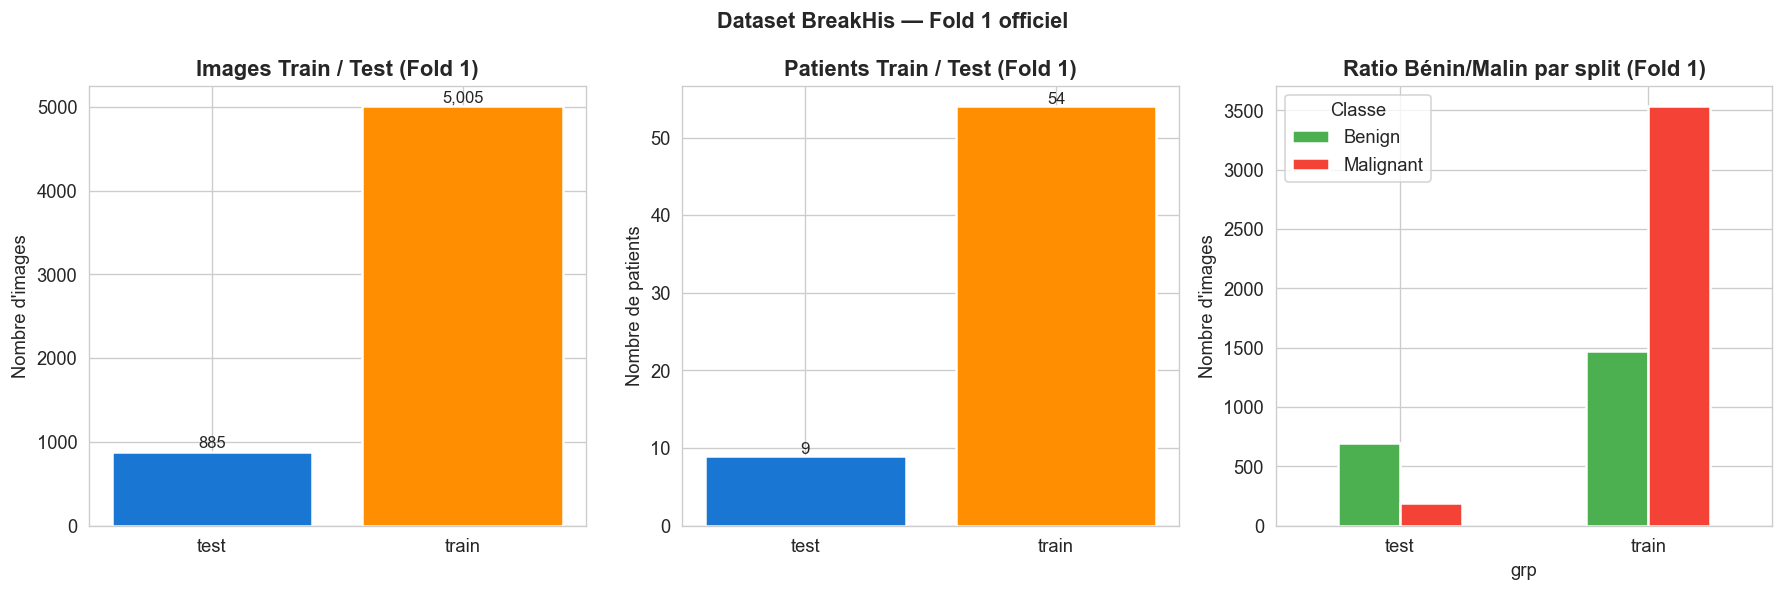

✅ Graphique sauvegardé : eda_07_fold1_split.png


In [56]:
# ── 6. Visualisation du split Fold 1 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Images train vs test
split_img = df_fold1_full.groupby('grp').size()
axes[0].bar(split_img.index, split_img.values,
            color=['#1976D2', '#FF8F00'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Images Train / Test (Fold 1)', fontweight='bold')
axes[0].set_ylabel("Nombre d'images")
for i, (k, v) in enumerate(split_img.items()):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# (b) Patients train vs test
split_patients = df_fold1_full.groupby('grp')['patient_id'].nunique()
axes[1].bar(split_patients.index, split_patients.values,
            color=['#1976D2', '#FF8F00'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Patients Train / Test (Fold 1)', fontweight='bold')
axes[1].set_ylabel('Nombre de patients')
for i, (k, v) in enumerate(split_patients.items()):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=10)

# (c) Ratio Bénin/Malin par split
ratio_data = df_fold1_full.groupby(['grp', 'label']).size().unstack(fill_value=0)
ratio_data.plot(kind='bar', ax=axes[2],
                color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[2].set_title('Ratio Bénin/Malin par split (Fold 1)', fontweight='bold')
axes[2].set_ylabel("Nombre d'images")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(title='Classe')

plt.suptitle('Dataset BreakHis — Fold 1 officiel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'eda_07_fold1_split.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Graphique sauvegardé : eda_07_fold1_split.png")


  RÉPARTITION DES SOUS-TYPES PAR SPLIT (Fold 1)
  🟢 Adenosis                  | train:  253 (57%)  test:  191 (43%)
  🟢 Fibroadenoma              | train:  683 (77%)  test:  205 (23%)
  🟢 Phyllodes Tumor           | train:  218 (48%)  test:  235 (52%)
  🟢 Tubular Adenoma           | train:  318 (83%)  test:   66 (17%)
  🔴 Ductal Carcinoma          | train: 2313 (100%)  test:    0 (0%)
  🔴 Lobular Carcinoma         | train:  302 (100%)  test:    0 (0%)
  🔴 Mucinous Carcinoma        | train:  547 (81%)  test:  126 (19%)
  🔴 Papillary Carcinoma       | train:  371 (86%)  test:   62 (14%)


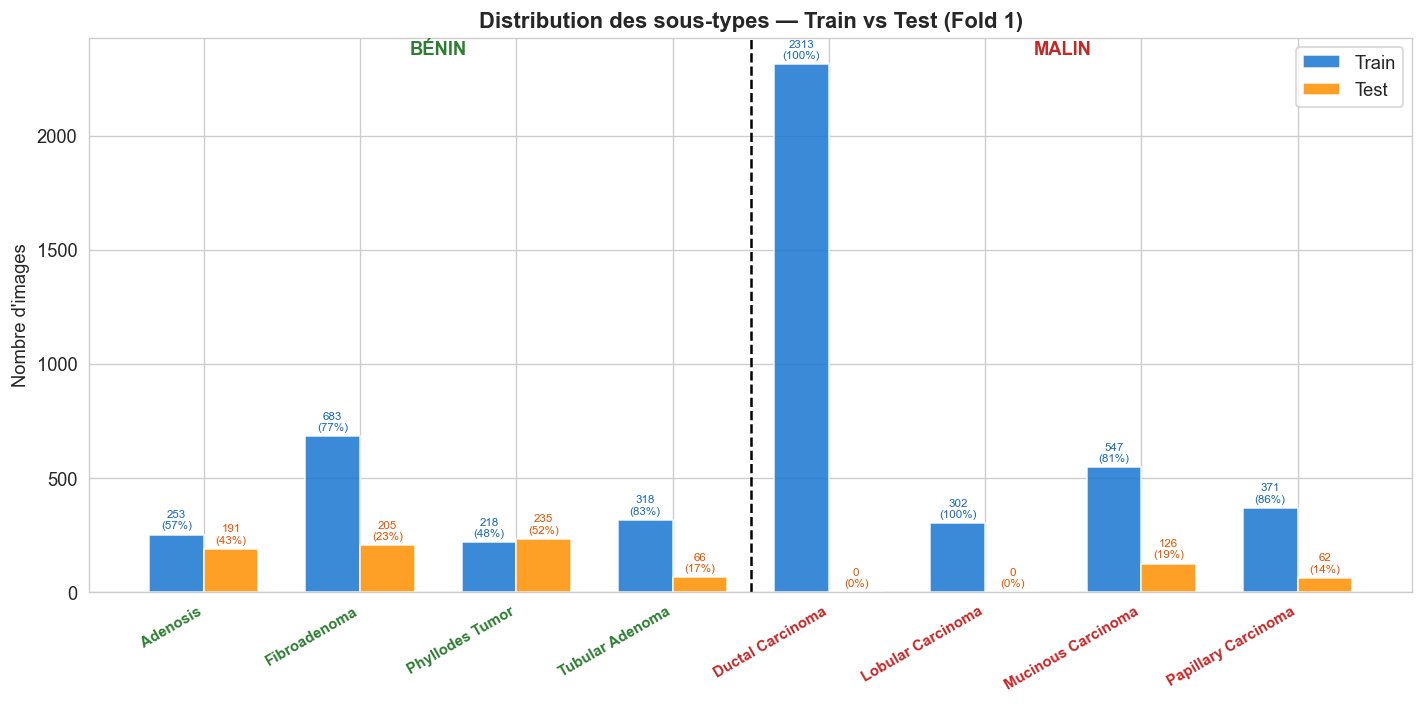

In [59]:
ordered_subtypes = benign_subtypes + malig_subtypes
subtype_split = subtype_split.reindex(columns=ordered_subtypes, fill_value=0)

# ── Résumé console ────────────────────────────────────────────────────
print("=" * 65)
print("  RÉPARTITION DES SOUS-TYPES PAR SPLIT (Fold 1)")
print("=" * 65)
for lbl in ordered_subtypes:
    n_train = subtype_split.loc['train', lbl]
    n_test  = subtype_split.loc['test',  lbl]
    total   = n_train + n_test
    flag    = '🟢' if lbl in benign_subtypes else '🔴'
    print(f"  {flag} {lbl:25s} | train: {n_train:4} ({n_train/total*100:.0f}%)  "
          f"test: {n_test:4} ({n_test/total*100:.0f}%)")

# ── Graphique ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(ordered_subtypes))
width = 0.35

bars_train = ax.bar(x - width/2, subtype_split.loc['train'], width,
                    label='Train', color='#1976D2', alpha=0.85)
bars_test  = ax.bar(x + width/2, subtype_split.loc['test'],  width,
                    label='Test',  color='#FF8F00', alpha=0.85)

# ── Annotations sur les barres : valeur + % ───────────────────────────
for bar, lbl in zip(bars_train, ordered_subtypes):
    n     = bar.get_height()
    total = subtype_split.loc['train', lbl] + subtype_split.loc['test', lbl]
    ax.text(bar.get_x() + bar.get_width()/2, n + 15,
            f"{n}\n({n/total*100:.0f}%)",
            ha='center', va='bottom', fontsize=7, color='#1565C0')

for bar, lbl in zip(bars_test, ordered_subtypes):
    n     = bar.get_height()
    total = subtype_split.loc['train', lbl] + subtype_split.loc['test', lbl]
    ax.text(bar.get_x() + bar.get_width()/2, n + 15,
            f"{n}\n({n/total*100:.0f}%)",
            ha='center', va='bottom', fontsize=7, color='#E65100')

# ── Labels X colorés ─────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(ordered_subtypes, rotation=30, ha='right', fontsize=9)
for tick, lbl in zip(ax.get_xticklabels(), ordered_subtypes):
    tick.set_color('#2E7D32' if lbl in benign_subtypes else '#C62828')
    tick.set_fontweight('bold')

ax.set_title('Distribution des sous-types — Train vs Test (Fold 1)', fontweight='bold')
ax.set_ylabel("Nombre d'images")
ax.legend()
ax.axvline(3.5, color='black', linewidth=1.5, linestyle='--')
ymax = ax.get_ylim()[1]
ax.text(1.5, ymax * 0.97, 'BÉNIN', ha='center', color='#2E7D32', fontweight='bold')
ax.text(5.5, ymax * 0.97, 'MALIN', ha='center', color='#C62828', fontweight='bold')

plt.tight_layout()
plt.savefig(GRAPH_PATH / 'eda_08_subtype_split_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 13. Résumé & export du DataFrame

In [60]:
print("=" * 55)
print("  RÉSUMÉ DE L'EDA — DATASET BREAKHIS")
print("=" * 55)
print(f"  Images totales      : {len(df):,}")
print(f"  Patients distincts  : {df['patient_id'].nunique()}")
print(f"  Bénin               : {(df['label']=='Benign').sum():,} ({(df['label']=='Benign').mean()*100:.1f}%)")
print(f"  Malin               : {(df['label']=='Malignant').sum():,} ({(df['label']=='Malignant').mean()*100:.1f}%)")
print(f"  Déséquilibre ratio  : 1:{(df['label']=='Malignant').sum()/(df['label']=='Benign').sum():.2f}")
print(f"  Grossissements      : 40×, 100×, 200×, 400×")
print(f"  Sous-types          : {df['subtype'].nunique()} ({', '.join(sorted(df['subtype'].unique()))})")
print()
print("  Statistiques RGB (échantillon 500 images) :")
print(f"  Moyenne : {[round(v,3) for v in DATASET_MEAN]}")
print(f"  Std     : {[round(v,3) for v in DATASET_STD]}")
print()
print("  Observations importantes :")
print("  1. Déséquilibre ~1:2.2 → WeightedSampler + WeightedLoss nécessaires")
print("  2. Split OFFICIEL via Fold 1 (Folds.csv) — colonne 'grp' ajoutée")
print("  3. Normalisation ImageNet justifiée (stats RGB proches)")
print()

# ── Export du DataFrame enrichi (avec colonne 'grp' du Fold 1) ───────────────
# On exporte df_merged (qui contient la colonne 'grp' pour les images du Fold 1)
output_path = Path('../data/breakhis_metadata.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df_merged.to_csv(output_path, index=False)

print(f"✅ Métadonnées sauvegardées : {output_path}")
print("   Colonnes exportées :", df_merged.columns.tolist())
print()
print("   → Ce fichier sera chargé dans 02_Preprocessing_Split.ipynb")
print("   → La colonne 'grp' (train/test/NaN) est déjà intégrée pour le Fold 1")
print("   → 02_Preprocessing will carve out val set from train patients (15%)")


  RÉSUMÉ DE L'EDA — DATASET BREAKHIS
  Images totales      : 7,909
  Patients distincts  : 81
  Bénin               : 2,480 (31.4%)
  Malin               : 5,429 (68.6%)
  Déséquilibre ratio  : 1:2.19
  Grossissements      : 40×, 100×, 200×, 400×
  Sous-types          : 8 (Adenosis, Ductal Carcinoma, Fibroadenoma, Lobular Carcinoma, Mucinous Carcinoma, Papillary Carcinoma, Phyllodes Tumor, Tubular Adenoma)

  Statistiques RGB (échantillon 500 images) :
  Moyenne : [0.784, 0.627, 0.76]
  Std     : [0.103, 0.135, 0.086]

  Observations importantes :
  1. Déséquilibre ~1:2.2 → WeightedSampler + WeightedLoss nécessaires
  2. Split OFFICIEL via Fold 1 (Folds.csv) — colonne 'grp' ajoutée
  3. Normalisation ImageNet justifiée (stats RGB proches)

✅ Métadonnées sauvegardées : ..\data\breakhis_metadata.csv
   Colonnes exportées : ['path', 'filename', 'label', 'label_int', 'subtype_code', 'subtype', 'patient_id', 'magnification', 'grp']

   → Ce fichier sera chargé dans 02_Preprocessing_Split.ip